# Customer Churn Prediction — Random Forest Classifier

**Goal :** Predict whether a customer will churn or not using Random Forest.  
**Dataset :** `customer_churn_dataset.xlsx`  
**Target :** `Churn` → Yes / No


### Importing Libraries
All required libraries are imported here.  
`warnings.filterwarnings("ignore")` keeps the output clean by suppressing unnecessary warnings.  
`sklearn` provides everything we need — model, metrics, and preprocessing.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

### Loading the Data
We load the Excel file using pandas.  
`df.head()` shows the first 5 rows so we can quickly understand the structure and columns.


In [2]:
df = pd.read_excel("customer_churn_dataset.xlsx")
df

,Age,Gender,Tenure_Months,Monthly_Spend($),Num_Purchases,Days_Since_Last_Purchase,Num_Complaints,Satisfaction_Score,Loyalty_Program,Num_Support_Calls,Avg_Session_Time(min),Discount_Used,Region,Churn
0,56,Male,36,1003.33,6,200,3,4.8,Yes,12,51.0,Yes,North,No
1,69,Female,6,4865.72,14,306,4,3.3,Yes,1,1.6,No,East,No
2,46,Female,39,1296.74,32,12,1,3.2,Yes,3,24.8,Yes,North,No
3,32,Male,42,4891.77,35,345,9,1.2,No,2,54.5,No,North,Yes
4,60,Male,58,2753.18,10,188,0,1.3,Yes,6,44.7,No,South,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,59,Female,48,2151.47,1,207,1,3.1,No,8,46.3,Yes,South,No
1196,69,Female,56,4535.32,10,28,5,2.1,No,4,6.3,No,North,No
1197,32,Female,65,3098.48,43,170,9,2.8,No,14,13.5,No,North,Yes
1198,64,Male,31,2967.75,16,336,2,2.9,Yes,14,30.6,No,North,Yes


In [3]:
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

  Rows    : 1200
  Columns : 14


### Basic Info & Missing Values
`df.info()` shows the datatype and non-null count for every column.  
`isnull().sum()` tells us if any values are missing — these need to be handled before modeling.  
`duplicated().sum()` catches repeated rows which can bias the model.  
We also check the churn distribution — if 90% are "No" and 10% "Yes", we have a class imbalance problem.


In [4]:
print(df.info())
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1200 non-null   int64  
 1   Gender                    1200 non-null   object 
 2   Tenure_Months             1200 non-null   int64  
 3   Monthly_Spend($)          1200 non-null   float64
 4   Num_Purchases             1200 non-null   int64  
 5   Days_Since_Last_Purchase  1200 non-null   int64  
 6   Num_Complaints            1200 non-null   int64  
 7   Satisfaction_Score        1200 non-null   float64
 8   Loyalty_Program           1200 non-null   object 
 9   Num_Support_Calls         1200 non-null   int64  
 10  Avg_Session_Time(min)     1200 non-null   float64
 11  Discount_Used             1200 non-null   object 
 12  Region                    1200 non-null   object 
 13  Churn                     1200 non-null   object 
dtypes: float

### Descriptive Statistics
`describe()` gives us mean, std, min and max — a quick feel for the data.  
`CV%` (Coefficient of Variation) = std/mean × 100. Features with higher CV% vary more and tend to be more useful for prediction.


In [5]:
feature_cols = [
    "Age", "Tenure_Months", "Monthly_Spend($)", "Num_Purchases",
    "Days_Since_Last_Purchase", "Num_Complaints", "Satisfaction_Score",
    "Num_Support_Calls", "Avg_Session_Time(min)"
]

desc = df[feature_cols].describe().T
desc["cv%"] = (desc["std"] / desc["mean"] * 100).round(1)
print(desc[["mean", "std", "min", "max", "cv%"]])

                                 mean          std     min      max   cv%
Age                         43.627500    15.052881   18.00    69.00  34.5
Tenure_Months               35.136667    20.315600    1.00    71.00  57.8
Monthly_Spend($)          2680.126317  1374.045595  202.13  4998.63  51.3
Num_Purchases               25.178333    14.190114    1.00    49.00  56.4
Days_Since_Last_Purchase   177.401667   105.387922    1.00   364.00  59.4
Num_Complaints               4.477500     2.896230    0.00     9.00  64.7
Satisfaction_Score           2.973500     1.157280    1.00     5.00  38.9
Num_Support_Calls            7.207500     4.244344    0.00    14.00  58.9
Avg_Session_Time(min)       29.880917    16.469841    1.00    59.90  55.1


### EDA — Colour Palette & Theme Setup
We set a consistent dark professional theme across all plots.  
Each color has a meaning: teal = No Churn (safe), pink-red = Churn (danger), other accents make graphs visually rich.


In [6]:
BG     = "#0a0e1a"
CARD   = "#0f1623"
BORDER = "#1c2a3a"
C0     = "#00e5b0"   # No Churn  — bright teal
C1     = "#ff4d6d"   # Churn     — hot pink-red
C2     = "#7b5ea7"   # accent    — purple
C3     = "#ffaa00"   # accent    — golden amber
C4     = "#00b4d8"   # accent    — sky blue
C5     = "#f72585"   # accent    — magenta
TEXT   = "#e2eaf5"
MUTED  = "#4a6480"
GOLD   = "#ffd60a"

plt.rcParams.update({
    "figure.facecolor" : BG,
    "axes.facecolor"   : CARD,
    "axes.edgecolor"   : BORDER,
    "axes.labelcolor"  : TEXT,
    "xtick.color"      : MUTED,
    "ytick.color"      : MUTED,
    "text.color"       : TEXT,
    "grid.color"       : BORDER,
    "grid.linewidth"   : 0.5,
    "font.family"      : "monospace",
    "axes.titlesize"   : 11,
    "axes.titleweight" : "bold",
    "axes.titlecolor"  : TEXT,
})

def section(title):
    print(f"\n{'='*62}")
    print(f"  {title}")
    print(f"{'='*62}")

##### 1. Churn Count
First step is always to understand the target variable.  
Bar chart shows absolute counts, pie chart shows proportions — both together give a complete picture.


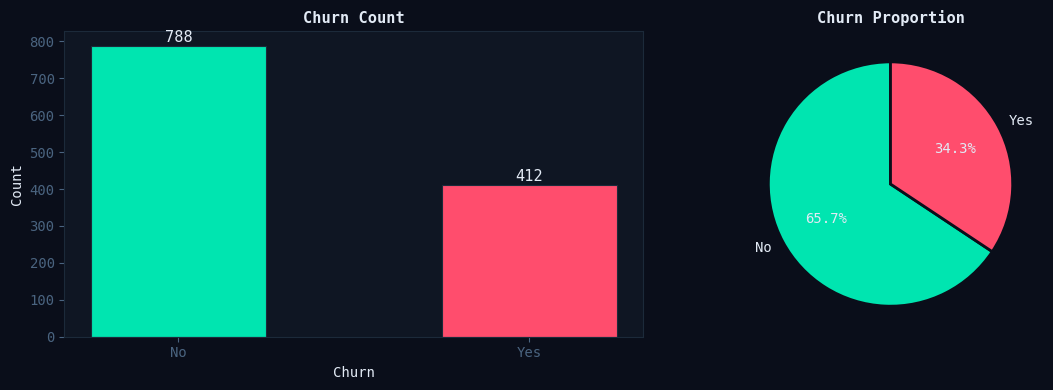

In [7]:
cts = df["Churn"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(BG)

axes[0].bar(cts.index, cts.values, color=[C0, C1], width=0.5, edgecolor=BORDER, linewidth=0.8)
axes[0].set_title("Churn Count")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
for i, (k, v) in enumerate(cts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", color=TEXT, fontsize=11)

axes[1].pie(cts.values, labels=cts.index, colors=[C0, C1],
            autopct="%1.1f%%", startangle=90,
            textprops={"color": TEXT}, wedgeprops={"edgecolor": BG, "linewidth": 2})
axes[1].set_title("Churn Proportion")

plt.tight_layout()
plt.show()

##### 2. Age Distribution
We check if churned customers have a different age profile.  
Overlapping histograms let us compare both groups in a single chart — any visible shift means age is a useful predictor.


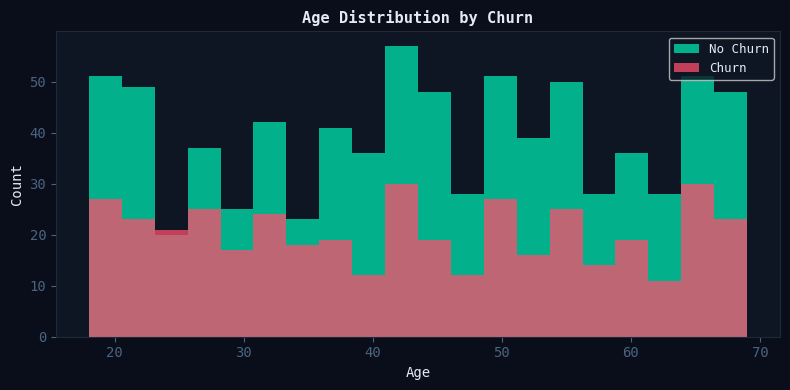

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Churn"] == "No"]["Age"],  bins=20, alpha=0.75, color=C0, label="No Churn")
plt.hist(df[df["Churn"] == "Yes"]["Age"], bins=20, alpha=0.75, color=C1, label="Churn")
plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### 3. Tenure Distribution
Newer customers (low tenure) tend to churn more — this is a very common business pattern.  
If churned customers are mostly in the low tenure range, tenure will likely be a top feature in our model.


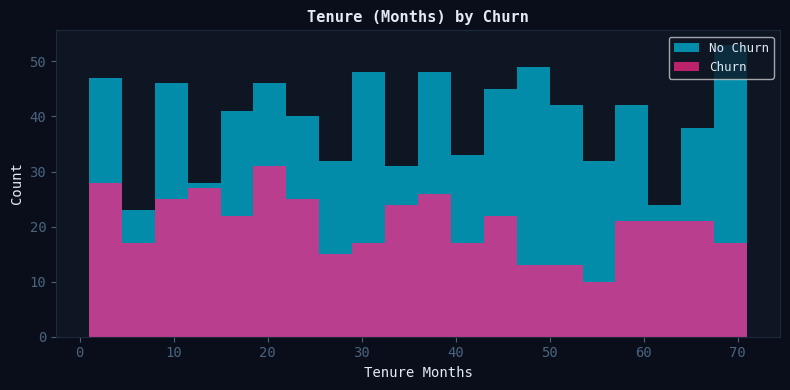

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Churn"] == "No"]["Tenure_Months"],  bins=20, alpha=0.75, color=C4, label="No Churn")
plt.hist(df[df["Churn"] == "Yes"]["Tenure_Months"], bins=20, alpha=0.75, color=C5, label="Churn")
plt.title("Tenure (Months) by Churn")
plt.xlabel("Tenure Months")
plt.ylabel("Count")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### 4. Monthly Spend & Complaints
Box plots show median, spread, and outliers all at once.  
If churned customers have more complaints — service quality is the main issue.  
If high spenders are also churning — it points to unmet expectations rather than pricing.


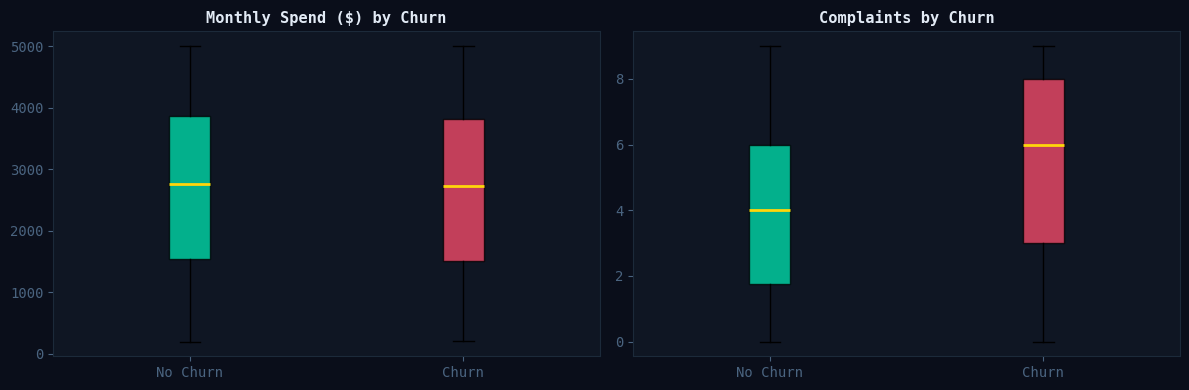

In [10]:
groups_spend = [df[df["Churn"] == v]["Monthly_Spend($)"].values for v in ["No", "Yes"]]
groups_comp  = [df[df["Churn"] == v]["Num_Complaints"].values  for v in ["No", "Yes"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(BG)

bp1 = axes[0].boxplot(groups_spend, patch_artist=True, labels=["No Churn", "Churn"],
                       medianprops={"color": GOLD, "linewidth": 2})
bp2 = axes[1].boxplot(groups_comp,  patch_artist=True, labels=["No Churn", "Churn"],
                       medianprops={"color": GOLD, "linewidth": 2})

for patch, col in zip(bp1["boxes"], [C0, C1]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for patch, col in zip(bp2["boxes"], [C0, C1]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

axes[0].set_title("Monthly Spend ($) by Churn")
axes[1].set_title("Complaints by Churn")
plt.tight_layout()
plt.show()

##### 5. Satisfaction Score
Low satisfaction = unhappy customer = likely to churn.  
If churned customers are mostly scoring 1–2, this is the strongest signal in the entire dataset.


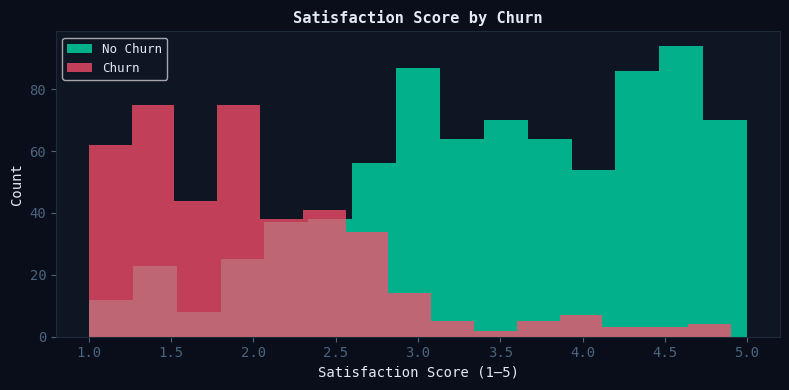

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Churn"] == "No"]["Satisfaction_Score"],  bins=15, alpha=0.75, color=C0, label="No Churn")
plt.hist(df[df["Churn"] == "Yes"]["Satisfaction_Score"], bins=15, alpha=0.75, color=C1, label="Churn")
plt.title("Satisfaction Score by Churn")
plt.xlabel("Satisfaction Score (1–5)")
plt.ylabel("Count")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### 6. Support Calls
More support calls = frustrated customer.  
When combined with low satisfaction, both high support calls AND low satisfaction together strongly predict churn.


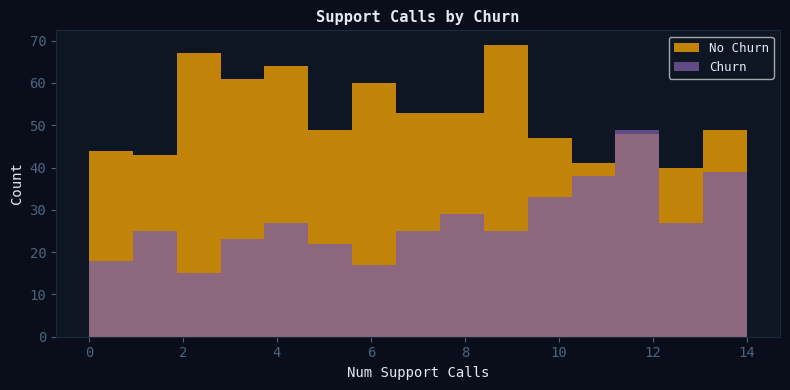

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Churn"] == "No"]["Num_Support_Calls"],  bins=15, alpha=0.75, color=C3, label="No Churn")
plt.hist(df[df["Churn"] == "Yes"]["Num_Support_Calls"], bins=15, alpha=0.75, color=C2, label="Churn")
plt.title("Support Calls by Churn")
plt.xlabel("Num Support Calls")
plt.ylabel("Count")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### 7. Correlation Heatmap
Shows pairwise linear relationships between all numeric features.  
+1 = strong positive, -1 = strong negative, ~0 = no relationship.  
Highly correlated features may be redundant — Random Forest handles this naturally but it's good to be aware.


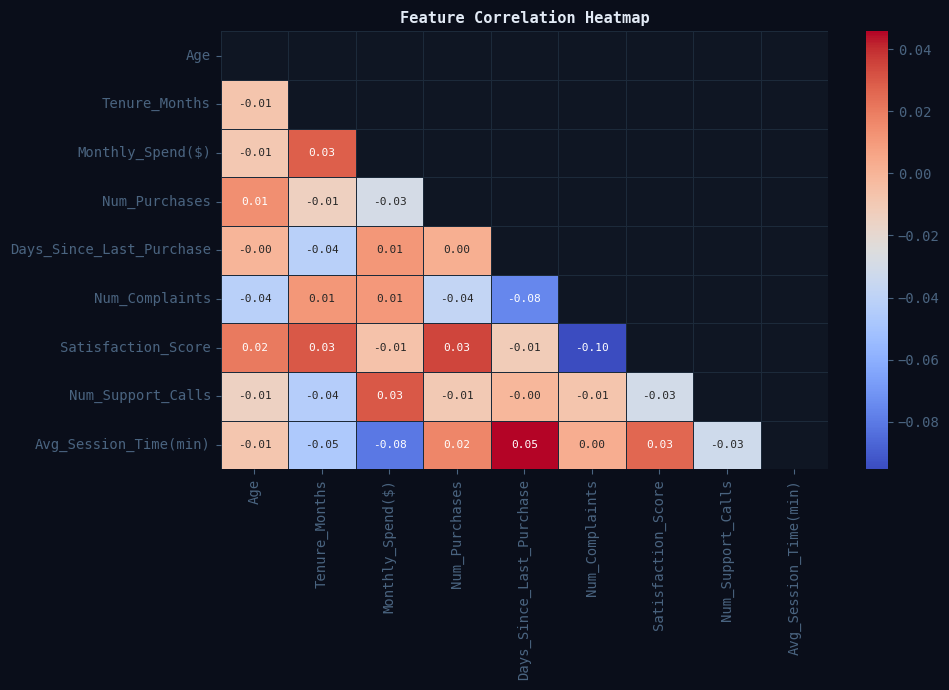

In [13]:
plt.figure(figsize=(10, 7))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor=BORDER, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Feature Engineering
We create new meaningful features from existing ones — this improves model accuracy and shows domain thinking.  
`spend_per_month` tells us how much value a customer generates per month.  
`churn_risk_score` is a combined metric: complaints + support calls − satisfaction. Higher = more at risk.


In [14]:
df["spend_per_month"]     = df["Monthly_Spend($)"] / (df["Tenure_Months"] + 1)
df["complaints_per_call"] = df["Num_Complaints"] / (df["Num_Support_Calls"] + 1)
df["engagement_score"]    = df["Avg_Session_Time(min)"] * df["Num_Purchases"]
df["churn_risk_score"]    = df["Num_Complaints"] + df["Num_Support_Calls"] - df["Satisfaction_Score"]

print("Engineered features added ✔")
print(df[["spend_per_month", "complaints_per_call", "engagement_score", "churn_risk_score"]].head())

Engineered features added ✔
   spend_per_month  complaints_per_call  engagement_score  churn_risk_score
0        27.117027             0.230769             306.0              10.2
1       695.102857             2.000000              22.4               1.7
2        32.418500             0.250000             793.6               0.8
3       113.762093             3.000000            1907.5               9.8
4        46.664068             0.000000             447.0               4.7


### Encoding Categorical Variables
Machine learning models only understand numbers, not text.  
Binary columns (Yes/No, Male/Female) are converted to 1/0.  
`pd.get_dummies()` creates a separate column for each region — this avoids giving false ordinal meaning.  
`LabelEncoder` converts the target column: Yes → 1, No → 0.


In [15]:
df["Gender_enc"]   = (df["Gender"]          == "Male").astype(int)
df["Loyalty_enc"]  = (df["Loyalty_Program"] == "Yes").astype(int)
df["Discount_enc"] = (df["Discount_Used"]   == "Yes").astype(int)

region_dummies = pd.get_dummies(df["Region"], prefix="Region").astype(int)
df = pd.concat([df, region_dummies], axis=1)

le = LabelEncoder()
df["Churn_encoded"] = le.fit_transform(df["Churn"])

print("Encoding done ✔")
print(f"Churn mapping : No → 0, Yes → 1")

Encoding done ✔
Churn mapping : No → 0, Yes → 1


### Define Features (X) and Target (y)
`X` contains all input features — what the model learns from.  
`y` contains only the target — what we want to predict (Churn: 0 or 1).  
The original `Churn` column is excluded from features — including it would cause data leakage.


In [16]:
feature_list = [
    "Age", "Tenure_Months", "Monthly_Spend($)", "Num_Purchases",
    "Days_Since_Last_Purchase", "Num_Complaints", "Satisfaction_Score",
    "Num_Support_Calls", "Avg_Session_Time(min)",
    "spend_per_month", "complaints_per_call", "engagement_score", "churn_risk_score",
    "Gender_enc", "Loyalty_enc", "Discount_enc",
    "Region_East", "Region_North", "Region_South", "Region_West"
]

X = df[feature_list]
y = df["Churn_encoded"]

print("X shape:", X.shape)
print("Features:", feature_list)

X shape: (1200, 20)
Features: ['Age', 'Tenure_Months', 'Monthly_Spend($)', 'Num_Purchases', 'Days_Since_Last_Purchase', 'Num_Complaints', 'Satisfaction_Score', 'Num_Support_Calls', 'Avg_Session_Time(min)', 'spend_per_month', 'complaints_per_call', 'engagement_score', 'churn_risk_score', 'Gender_enc', 'Loyalty_enc', 'Discount_enc', 'Region_East', 'Region_North', 'Region_South', 'Region_West']


### Train-Test Split
Data is split into 80% training and 20% testing.  
`stratify=y` ensures both sets have the same churn ratio — critical for imbalanced data.  
`random_state=42` makes the split reproducible — same result every time.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  Training set : {X_train.shape[0]} samples")
print(f"  Test set     : {X_test.shape[0]} samples")
print(f"\nChurn ratio — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")

  Training set : 960 samples
  Test set     : 240 samples

Churn ratio — Train: 0.344  |  Test: 0.342


### Final Random Forest Model
Random Forest = many Decision Trees combined. Each tree trains on slightly different data, and the final answer is a majority vote.  
`n_estimators=200` — we build 200 trees.  
`max_depth=10` — limits tree depth to prevent overfitting.  
`class_weight="balanced"` — automatically gives more weight to the minority class (churned customers).  
`n_jobs=-1` — uses all CPU cores for faster training.


In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Trees trained   :", rf.n_estimators)
print("Features used   :", rf.n_features_in_)
print("Classes         :", rf.classes_)

Trees trained   : 200
Features used   : 20
Classes         : [0 1]


### Evaluation Metrics
Accuracy alone is not enough — especially with imbalanced data.  
**Precision** — of all predicted churners, how many actually churned?  
**Recall** — of all actual churners, how many did we catch? (Most important metric for churn)  
**F1 Score** — balances precision and recall into a single number.  
**ROC-AUC** — overall model quality regardless of threshold (1.0 = perfect, 0.5 = random guess).


In [19]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy       :", round(accuracy_score(y_test, y_pred),  4))
print("Precision      :", round(precision_score(y_test, y_pred), 4))
print("Recall         :", round(recall_score(y_test, y_pred),    4))
print("F1 Score       :", round(f1_score(y_test, y_pred),        4))
print("ROC-AUC Score  :", round(roc_auc_score(y_test, y_prob),   4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy       : 0.9417
Precision      : 0.9474
Recall         : 0.878
F1 Score       : 0.9114
ROC-AUC Score  : 0.9851

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.97      0.96       158
       Churn       0.95      0.88      0.91        82

    accuracy                           0.94       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.94      0.94      0.94       240



##### Confusion Matrix
Shows 4 outcomes — True Positive, True Negative, False Positive, False Negative.  
**False Negative** (missing a churner) is the most costly — the customer leaves without any retention effort.  
**False Positive** (wrong alarm) just wastes a small retention budget — far more acceptable.


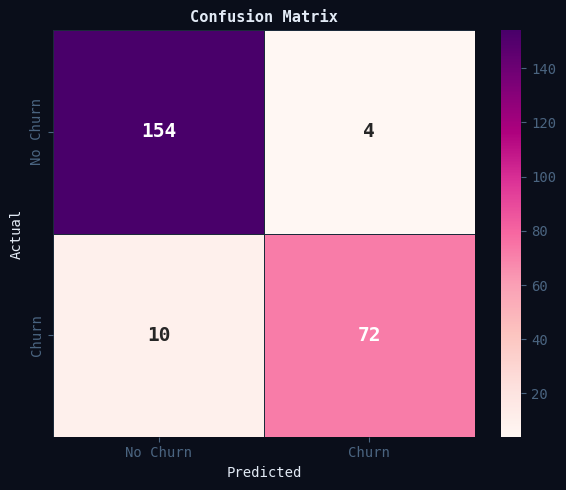

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            linewidths=0.5, linecolor=BORDER,
            annot_kws={"size": 14, "weight": "bold"})
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

##### ROC Curve
Shows model performance across every possible probability threshold.  
X-axis = False Positive Rate, Y-axis = True Positive Rate (Recall).  
The closer the curve is to the top-left corner, the better the model.  
The diagonal line represents random guessing — our AUC should be well above that.


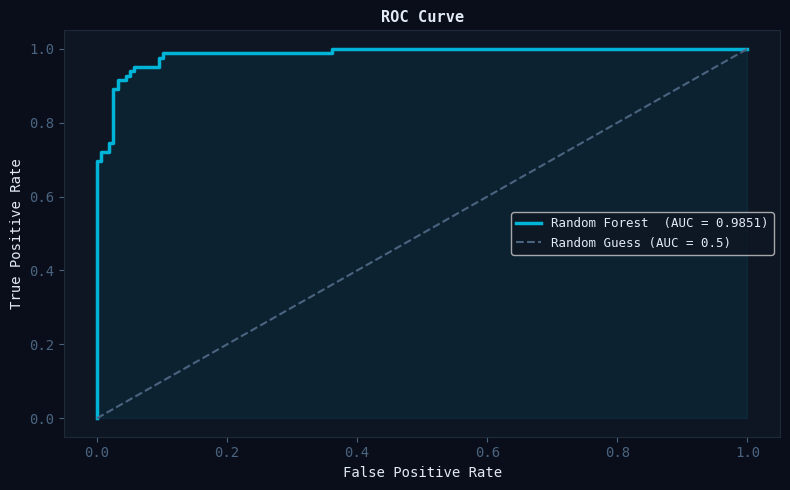

In [21]:
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color=C4, linewidth=2.5, label=f"Random Forest  (AUC = {auc:.4f})")
plt.fill_between(fpr, tpr, alpha=0.08, color=C4)
plt.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1.5, label="Random Guess (AUC = 0.5)")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### Feature Importance
Random Forest tells us which features contributed the most to predictions.  
This gives us business insight — we can tell the recruiter exactly what drives churn in this dataset.  
Features above the gold dotted line (mean importance) are the most impactful.


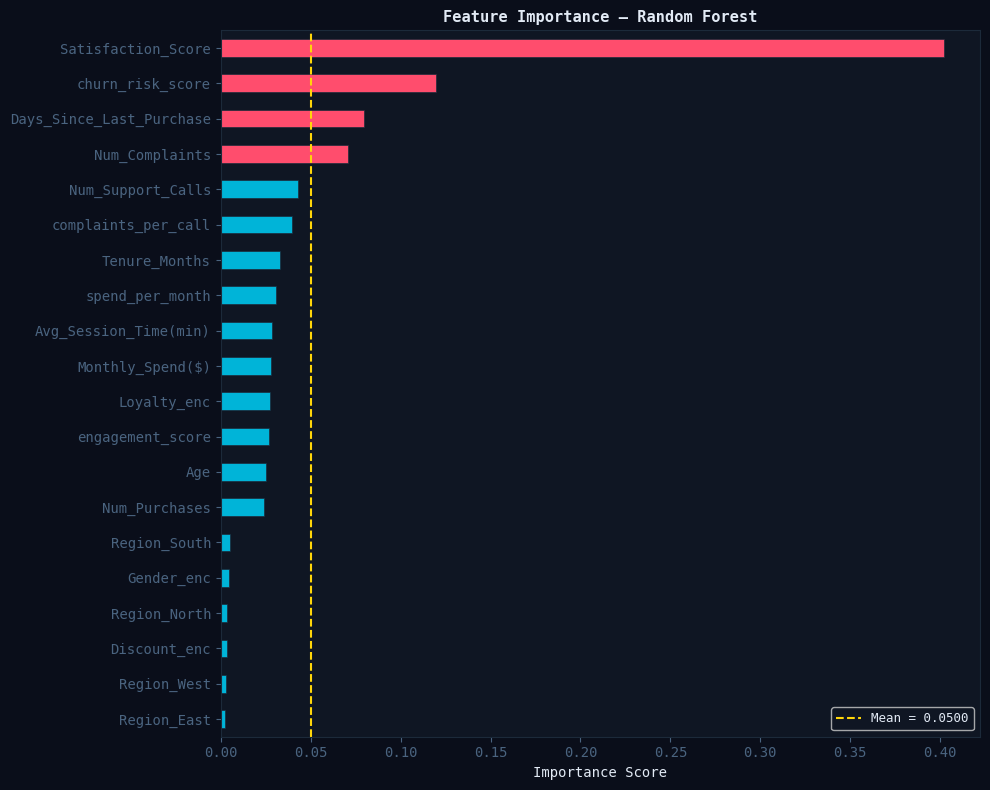


Top 10 Features:
Satisfaction_Score          0.4020
churn_risk_score            0.1195
Days_Since_Last_Purchase    0.0794
Num_Complaints              0.0708
Num_Support_Calls           0.0428
complaints_per_call         0.0395
Tenure_Months               0.0330
spend_per_month             0.0306
Avg_Session_Time(min)       0.0287
Monthly_Spend($)            0.0278
dtype: float64


In [22]:
importances = pd.Series(rf.feature_importances_, index=feature_list)
importances_sorted = importances.sort_values()

colors = [C1 if v > importances.mean() else C4 for v in importances_sorted.values]

plt.figure(figsize=(10, 8))
importances_sorted.plot(kind="barh", color=colors, edgecolor=BORDER, linewidth=0.5)
plt.axvline(importances.mean(), color=GOLD, linestyle="--", linewidth=1.5,
            label=f"Mean = {importances.mean():.4f}")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(importances.sort_values(ascending=False).head(10).round(4))

### Cross-Validation
Relying on a single train-test split can be misleading — that particular split might be lucky or unlucky.  
5-Fold CV splits data into 5 parts, trains and tests 5 times, then averages the results.  
A low standard deviation means the model is stable and not overfitting.


In [23]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc", n_jobs=-1)

for i, score in enumerate(cv_scores, 1):
    bar = "█" * int(score * 30)
    print(f"  Fold {i}: {score:.4f}  {bar}")

print(f"\nMean AUC : {cv_scores.mean():.4f}")
print(f"Std  AUC : {cv_scores.std():.4f}")

  Fold 1: 0.9914  █████████████████████████████
  Fold 2: 0.9805  █████████████████████████████
  Fold 3: 0.9866  █████████████████████████████
  Fold 4: 0.9855  █████████████████████████████
  Fold 5: 0.9902  █████████████████████████████

Mean AUC : 0.9868
Std  AUC : 0.0038


### Hyperparameter Tuning
Default parameters are not always the best — GridSearchCV systematically tries every combination.  
`n_estimators` — how many trees? `max_depth` — how deep should trees go?  
`cv=3` means 3-fold cross-validation is run for each combination.  
The combination that maximizes ROC-AUC is selected as the best.


In [24]:
param_grid = {
    "n_estimators"      : [100, 200],
    "max_depth"         : [8, 10, 15],
    "min_samples_split" : [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Parameters:")
for param, val in grid.best_params_.items():
    print(f"  {param} : {val}")
print(f"\nBest Cross-Val AUC: {grid.best_score_:.4f}")

Best Parameters:
  max_depth : 10
  min_samples_split : 5
  n_estimators : 200

Best Cross-Val AUC: 0.9805


### Save Output
We save the final predictions along with churn probability scores.  
`Churn_Probability` helps the business team prioritize — a 0.92 score needs immediate action vs a 0.51.  
`Risk_Label` (Low / Medium / High) makes it easy for non-technical teams to act on the results.


In [25]:
df["Predicted_Churn"]   = rf.predict(X[feature_list])
df["Churn_Probability"] = rf.predict_proba(X[feature_list])[:, 1].round(4)
df["Risk_Label"] = pd.cut(df["Churn_Probability"],
                          bins=[0, 0.3, 0.6, 1.0],
                          labels=["Low Risk", "Medium Risk", "High Risk"])

df.to_csv("bird_clustered_output.csv", index=False)

print("Output saved ✔")
print("\nRisk Distribution:")
print(df["Risk_Label"].value_counts())
print("\nSample:")
print(df[["Age", "Tenure_Months", "Churn", "Churn_Probability", "Risk_Label"]].head(8).to_string(index=False))

Output saved ✔

Risk Distribution:
Risk_Label
Low Risk       755
High Risk      399
Medium Risk     45
Name: count, dtype: int64

Sample:
 Age  Tenure_Months Churn  Churn_Probability Risk_Label
  56             36    No             0.0268   Low Risk
  69              6    No             0.2596   Low Risk
  46             39    No             0.0025   Low Risk
  32             42   Yes             0.8367  High Risk
  60             58    No             0.1083   Low Risk
  25             12   Yes             0.9005  High Risk
  38              3   Yes             0.9237  High Risk
  56             18    No             0.1112   Low Risk
